<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Test/0_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Nanodegree

## Project: Image Captioning

---

The Microsoft **C**ommon **O**bjects in **CO**ntext (MS COCO) dataset is a large-scale dataset for scene understanding.  The dataset is commonly used to train and benchmark object detection, segmentation, and captioning algorithms.  

![Sample Dog Output](https://github.com/pradhapmoorthi/CVND/blob/Test/images/coco-examples.jpg?raw=1)

You can read more about the dataset on the [website](http://cocodataset.org/#home) or in the [research paper](https://arxiv.org/pdf/1405.0312.pdf).

In this notebook, you will explore this dataset, in preparation for the project.

## Step 1: Initialize the COCO API

We begin by initializing the [COCO API](https://github.com/cocodataset/cocoapi) that you will use to obtain the data.

In [2]:
import os
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO

# initialize COCO API for instance annotations
dataDir = '/opt/cocoapi'
dataType = 'val2014'

# --- Added code to download and extract annotations ---
annotations_dir = os.path.join(dataDir, 'annotations')

# Create directory if it doesn't exist
if not os.path.exists(annotations_dir):
    os.makedirs(annotations_dir)
    print(f"Created directory: {annotations_dir}")

# Check if annotation files exist before downloading
instances_annFile_path = os.path.join(annotations_dir, f'instances_{dataType}.json')
captions_annFile_path = os.path.join(annotations_dir, f'captions_{dataType}.json')

if not os.path.exists(instances_annFile_path) or not os.path.exists(captions_annFile_path):
    print("Annotation files not found. Downloading...")
    zip_file_path = os.path.join(dataDir, 'annotations_trainval2014.zip')

    # Download the zip file if it doesn't exist
    if not os.path.exists(zip_file_path):
        print(f"Downloading annotations_trainval2014.zip to {zip_file_path}...")
        # Use !wget for Colab environment to download directly
        !wget -nc http://images.cocodataset.org/annotations/annotations_trainval2014.zip -O {zip_file_path}
        print("Download complete.")
    else:
        print(f"annotations_trainval2014.zip already exists at {zip_file_path}.")

    print(f"Extracting annotations from {zip_file_path} to {dataDir}...")
    # Unzip into dataDir, which will create the 'annotations' folder inside dataDir
    !unzip -o {zip_file_path} -d {dataDir}
    print("Extraction complete.")
else:
    print("Annotation files already exist. Skipping download and extraction.")
# --- End of added code ---


instances_annFile = os.path.join(dataDir, 'annotations/instances_{}.json'.format(dataType))
coco = COCO(instances_annFile)

# initialize COCO API for caption annotations
captions_annFile = os.path.join(dataDir, 'annotations/captions_{}.json'.format(dataType))
coco_caps = COCO(captions_annFile)

# get image ids
ids = list(coco.anns.keys())

Created directory: /opt/cocoapi/annotations
Annotation files not found. Downloading...
--2026-02-24 19:51:42--  http://images.cocodataset.org/annotations/annotations_trainval2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.112.225, 54.231.172.161, 16.15.185.88, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.112.225|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252872794 (241M) [application/zip]
Saving to: ‘/opt/cocoapi/annotations_trainval2014.zip’

/opt/cocoapi/annota 100%[===================>] 241.16M  72.7MB/s    in 3.3s    

2026-02-24 19:51:45 (72.7 MB/s) - ‘/opt/cocoapi/annotations_trainval2014.zip’ saved [252872794/252872794]

Download complete.
Extracting annotations from /opt/cocoapi/annotations_trainval2014.zip to /opt/cocoapi...
Archive:  /opt/cocoapi/annotations_trainval2014.zip
  inflating: /opt/cocoapi/annotations/instances_train2014.json  
  inflating: /opt/cocoapi/annotations/instances_val2

## Step 2: Plot a Sample Image

Next, we plot a random image from the dataset, along with its five corresponding captions.  Each time you run the code cell below, a different image is selected.  

In the project, you will use this dataset to train your own model to generate captions from images!

http://images.cocodataset.org/val2014/COCO_val2014_000000527025.jpg


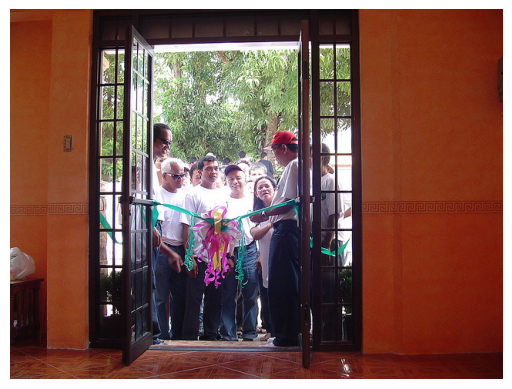

People standing outside doorway with ribbon across it.
A group of people standing outside of a doorway with a ribbon on it.
A group of people stand outside a building at a ribbon cutting.
Some people are waiting in an open doorway
This is a picture of a house warming party.


In [3]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
%matplotlib inline

# pick a random image and obtain the corresponding URL
ann_id = np.random.choice(ids)
img_id = coco.anns[ann_id]['image_id']
img = coco.loadImgs(img_id)[0]
url = img['coco_url']

# print URL and visualize corresponding image
print(url)
I = io.imread(url)
plt.axis('off')
plt.imshow(I)
plt.show()

# load and display captions
annIds = coco_caps.getAnnIds(imgIds=img['id']);
anns = coco_caps.loadAnns(annIds)
coco_caps.showAnns(anns)

## Step 3: What's to Come!

In this project, you will use the dataset of image-caption pairs to train a CNN-RNN model to automatically generate captions from images.  You'll learn more about how to design the architecture in the next notebook in the sequence (**1_Preliminaries.ipynb**).

![Image Captioning CNN-RNN model](https://github.com/pradhapmoorthi/CVND/blob/Test/images/encoder-decoder.png?raw=1)